# Demo: FOPT Parameters ($T_n$, $\alpha$, $\beta/H$)

This notebook demonstrates how to extract the macroscopic FOPT observables using `FOPTUtilities`.

**Pipeline step:** Fourth layer — takes $S_E(T, g_D)$ (from bounce solvers) and outputs the three numbers that characterize a FOPT:
- $T_n$: nucleation temperature (when one bubble per Hubble volume nucleates)
- $\alpha$: latent heat relative to radiation
- $\beta/H$: inverse duration of the transition

These three numbers are the input to the gravitational wave spectrum calculation.

**Modules used:** `src/RGE/FOPT_RGE_real.py` (real solvers) · `src/RGE/FOPT_RGE.py` (grid) · `src/RGE/BounceODE_RGE.py` (ODE solver)

**Contents:**
1. Nucleation temperature for a single $g_D$
2. FOPT parameters $\alpha$ and $\beta/H$ at that $g_D$
3. Scan: high-$T$ approximation (`is_HT=True`, Espinosa solver)
4. Save HT output
5. Scan: full $V_\text{eff}$ (`is_HT=False`, Espinosa solver)
6. Comparison: HT vs. Full (Espinosa)
7. Save Full output
8. Scan: pre-computed grid (`SEInterpolator`)
9. Three-way comparison: Grid vs. HT vs. Full
10. Save Grid output
11. Scan: ODE bounce solver (`BounceODE_RGE`) — HT and Full
12. Save ODE output
13. Five-way comparison: all methods

In [16]:
%load_ext autoreload
%autoreload 2

%run startup.py

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
startup.py loaded: numpy, scipy, matplotlib, and all project modules are ready.
  Use new_figure() to create pre-formatted plots.


In [17]:
# Instantiate the effective potential and the FOPT utilities
veff_obj = veff.VeffRGE(vt_table_path="VT_integralNumeric.dat")
fopt_obj = fopt_real.FOPTUtilities(veff_obj=veff_obj)

# Shared parameters for all calculations below
scale = np.pi     # renormalization scale factor (mu = pi * T)
ls0   = 1e-10     # initial scalar quartic coupling

## 1. Nucleation temperature $T_n$

`nucTemp` finds the root of the tunneling condition
$$\frac{S_E(T_n)}{T_n} = 4\ln T_n + \frac{3}{2}\ln\frac{S_E/(2\pi T_n)}{T_n^2} - 4\ln H(T_n)$$
using the high-$T$ approximation (`is_HT=True`). The full potential is used when `is_HT=False`.

In [18]:
gD_single = 0.8

Tn = fopt_obj.nucTemp(gD=gD_single, is_HT=True, scale=scale, ls0=ls0)
print(f"gD = {gD_single}")
print(f"Nucleation temperature  Tn = {Tn:.6f}")

/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceSolHighT_RGE.py:201: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result = quad(integrand, 0, phi0, limit=5_000, epsrel=1e-6, epsabs=1e-6)[0]


gD = 0.8
Nucleation temperature  Tn = 0.112041


## 2. FOPT parameters at a single $g_D$

- **$\alpha(T_n)$**: ratio of latent heat to radiation energy density
- **$\beta/H(T_n)$**: dimensionless inverse duration, $\beta/H = T_n (d\ln S_E/dT)|_{T_n}$

In [19]:
alpha_single = fopt_obj.alpha(Tn, gD_single, is_HT=True, scale=scale)
beta_single  = fopt_obj.beta(Tn, gD_single, is_HT=True, scale=scale)

print(f"Nucleation temperature  Tn    = {Tn:.6f}")
print(f"Supercooling parameter  alpha = {alpha_single:.4e}")
print(f"Inverse duration        beta  = {beta_single:.4f}")

Nucleation temperature  Tn    = 0.112041
Supercooling parameter  alpha = 6.8924e+00
Inverse duration        beta  = 128.3622


## 3. Scan over $g_D$

Loop over a grid of $g_D$ values to produce the curves $T_n(g_D)$, $\alpha(g_D)$, $\beta/H(g_D)$ that are the main output of this pipeline.

> **Note:** Each `nucTemp` call invokes the bounce solver directly. With the optimised solvers (vectorised scan, cached RGE, cached V0) this takes a few seconds per point.

In [ ]:
n_gD    = 20
gD_vals = np.linspace(0.5, 1.0, n_gD)

# --- Nucleation temperatures ---
Tn_vals = []
for gD in tqdm(gD_vals, desc="Computing Tn"):
    try:
        Tn_i = fopt_obj.nucTemp(gD=gD, is_HT=True, scale=scale, ls0=ls0)
    except Exception:
        Tn_i = np.nan
    Tn_vals.append(Tn_i)
Tn_vals = np.array(Tn_vals)

# --- Alpha and beta ---
alpha_vals = []
beta_vals  = []
for gD, Tn_i in zip(gD_vals, Tn_vals):
    if np.isfinite(Tn_i):
        try:
            alpha_vals.append(fopt_obj.alpha(Tn_i, gD, is_HT=True, scale=scale))
            beta_vals.append(fopt_obj.beta(Tn_i, gD, is_HT=True, scale=scale))
        except Exception:
            alpha_vals.append(np.nan)
            beta_vals.append(np.nan)
    else:
        alpha_vals.append(np.nan)
        beta_vals.append(np.nan)

alpha_vals = np.array(alpha_vals)
beta_vals  = np.array(beta_vals)

Computing Tn:   0%|          | 0/20 [00:00<?, ?it/s]/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceSolHighT_RGE.py:201: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  result = quad(integrand, 0, phi0, limit=5_000, epsrel=1e-6, epsabs=1e-6)[0]
/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/FOPT_RGE_real.py:99: RuntimeWarning: invalid value encountered in log10
  return float(np.log10(S3))
Computing Tn:  15%|█▌        | 3/20 [00:46<04:25, 15.61s/it]

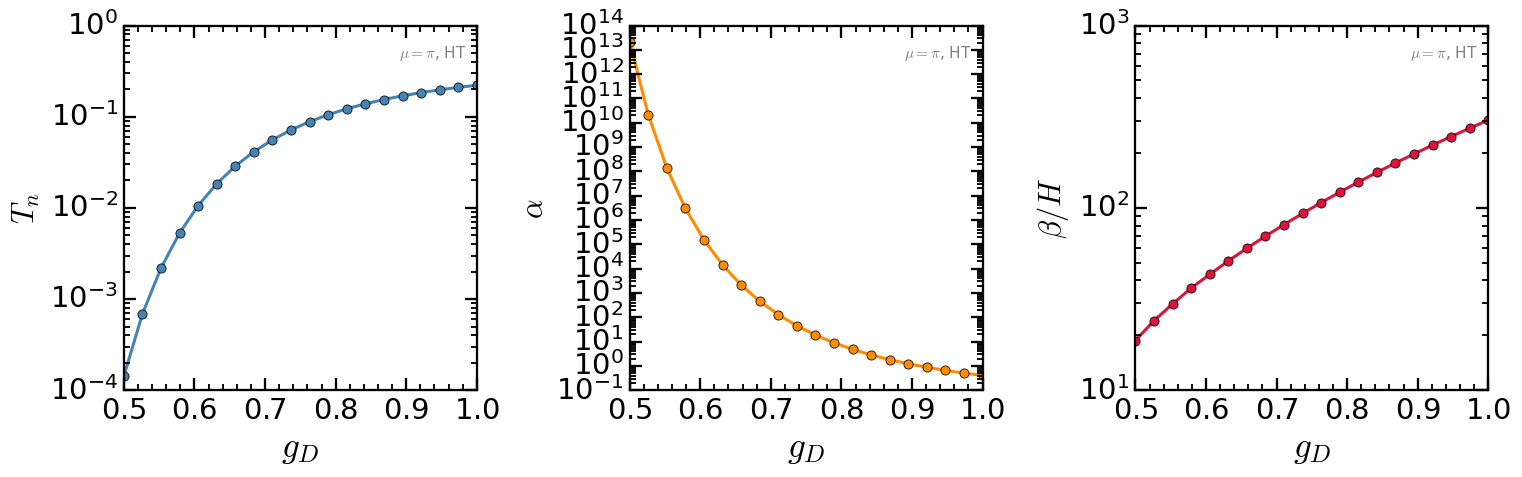

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=110)
fig.patch.set_facecolor('white')

# Tn vs gD
axes[0].plot(gD_vals, Tn_vals, 'o-', lw=2, color='steelblue')
ps.apply_standard_formatting(axes[0],ylog=True, xlabel=r'$g_D$', ylabel=r'$T_n$')

# alpha vs gD
axes[1].plot(gD_vals[np.isfinite(alpha_vals)], alpha_vals[np.isfinite(alpha_vals)],
             'o-', lw=2, color='darkorange')
ps.apply_standard_formatting(axes[1], ylog=True, xlabel=r'$g_D$', ylabel=r'$\alpha$')

# beta vs gD
axes[2].plot(gD_vals[np.isfinite(beta_vals)], beta_vals[np.isfinite(beta_vals)],
             'o-', lw=2, color='crimson')
ps.apply_standard_formatting(axes[2], ylog=True, xlabel=r'$g_D$', ylabel=r'$\beta/H$')

for ax_i in axes:
    ax_i.text(0.97, 0.95, fr'$\mu = \pi$, HT', transform=ax_i.transAxes,
              ha='right', va='top', fontsize=10, color='gray')

plt.tight_layout()

## 4. Save output data

The full $(g_D, T_n, \alpha, \beta/H)$ table is the final output of this pipeline stage and the direct input to `demo_GW_spectrum.ipynb`.

In [7]:
import os
os.makedirs("../data/final_data", exist_ok=True)

data_all = np.column_stack([gD_vals, Tn_vals, alpha_vals, beta_vals])

np.savetxt(
    "../data/final_data/gD_Tn_alpha_beta_RGE_piT_HT_all.dat",
    data_all,
    header="gD    Tn    alpha    beta",
    fmt="%.6e"
)
print("Saved: data/final_data/gD_Tn_alpha_beta_RGE_piT_HT_all.dat")
print(f"  {n_gD} rows, gD in [{gD_vals[0]:.2f}, {gD_vals[-1]:.2f}]")

Saved: data/final_data/gD_Tn_alpha_beta_RGE_piT_HT_all.dat
  20 rows, gD in [0.50, 1.00]


## 5. Scan with full $V_\text{eff}$

Repeat the $g_D$ scan using `is_HT=False`, which routes through `BounceSolver` (exact $J_B$ thermal integral) instead of the high-$T$ approximation.  The same `fopt_obj` instance is reused; only the `is_HT` flag changes.

> **Note:** The full solver is slower than the high-$T$ one. Expect roughly 2–5× longer run time per point.

In [31]:
n_gD_full    = 3
gD_vals_full = np.linspace(0.5, 1.0, n_gD_full)

# --- Nucleation temperatures (full Veff) ---
Tn_vals_full = []
for gD in tqdm(gD_vals_full, desc="Computing Tn (Full)"):
    try:
        Tn_i = fopt_obj.nucTemp(gD=gD, is_HT=False, scale=scale, ls0=ls0)
    except Exception:
        Tn_i = np.nan
    Tn_vals_full.append(Tn_i)
Tn_vals_full = np.array(Tn_vals_full)

# --- Alpha and beta (full Veff) ---
alpha_vals_full = []
beta_vals_full  = []
for gD, Tn_i in zip(gD_vals_full, Tn_vals_full):
    if np.isfinite(Tn_i):
        try:
            alpha_vals_full.append(fopt_obj.alpha(Tn_i, gD, is_HT=False, scale=scale))
            beta_vals_full.append(fopt_obj.beta(Tn_i, gD, is_HT=False, scale=scale))
        except Exception:
            alpha_vals_full.append(np.nan)
            beta_vals_full.append(np.nan)
    else:
        alpha_vals_full.append(np.nan)
        beta_vals_full.append(np.nan)

alpha_vals_full = np.array(alpha_vals_full)
beta_vals_full  = np.array(beta_vals_full)


Computing Tn (Full): 100%|██████████| 3/3 [04:21<00:00, 87.02s/it] 


In [33]:
Tn_vals_full

array([1.40332274e-04, 7.73155327e-02, 2.12240718e-01])

## 6. Comparison: HT vs. Full

Plot $T_n(g_D)$, $\alpha(g_D)$, and $\beta/H(g_D)$ for both approximations in the same panels to assess where the high-$T$ approximation breaks down.

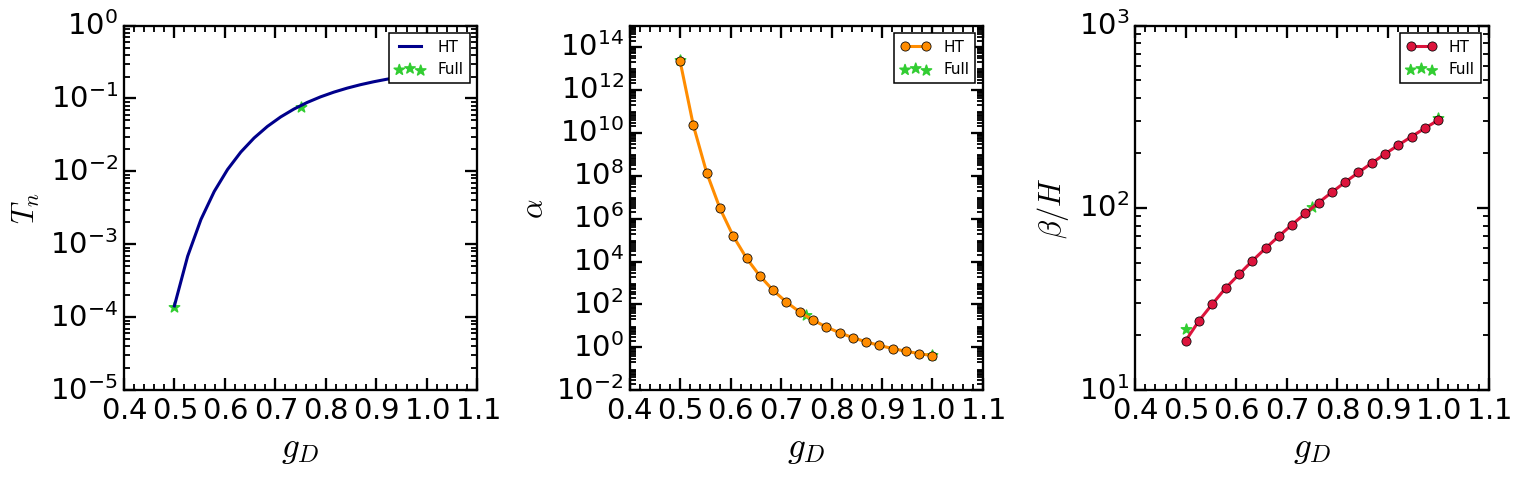

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=110)
fig.patch.set_facecolor('white')

mask_ht   = np.isfinite(Tn_vals)
mask_full = np.isfinite(Tn_vals_full)

# Tn vs gD
axes[0].plot(gD_vals[mask_ht], Tn_vals[mask_ht],  lw=2, color='darkblue',  label='HT')
axes[0].scatter(gD_vals_full[mask_full], Tn_vals_full[mask_full],  s=50, marker='*', color='limegreen',  label='Full')
ps.apply_standard_formatting(axes[0], ylog=True, xlabel=r'$g_D$', ylabel=r'$T_n$')
axes[0].legend(fontsize=10)

# alpha vs gD
mask_a_ht   = mask_ht   & np.isfinite(alpha_vals)
mask_a_full = mask_full & np.isfinite(alpha_vals_full)
axes[1].plot(gD_vals[mask_a_ht],      alpha_vals[mask_a_ht],         'o-',  lw=2, color='darkorange', label='HT')
axes[1].scatter(gD_vals_full[mask_a_full], alpha_vals_full[mask_a_full], s=50, marker='*', color='limegreen',  label='Full')
ps.apply_standard_formatting(axes[1], ylog=True, xlabel=r'$g_D$', ylabel=r'$\alpha$')
axes[1].legend(fontsize=10)

# beta vs gD
mask_b_ht   = mask_ht   & np.isfinite(beta_vals)
mask_b_full = mask_full & np.isfinite(beta_vals_full)
axes[2].plot(gD_vals[mask_b_ht],      beta_vals[mask_b_ht],         'o-',  lw=2, color='crimson',   label='HT')
axes[2].scatter(gD_vals_full[mask_b_full], beta_vals_full[mask_b_full], s=50, marker='*', color='limegreen', label='Full')
ps.apply_standard_formatting(axes[2], ylog=True, xlabel=r'$g_D$', ylabel=r'$\beta/H$')
axes[2].legend(fontsize=10)

for ax_i in axes:
    ax_i.text(0.97, 0.95, fr'$\mu = \pi T$', transform=ax_i.transAxes,
              ha='right', va='top', fontsize=10, color='gray')

plt.tight_layout()

## 7. Save Full output

Save the $(g_D, T_n, \alpha, \beta/H)$ table computed with the full $V_\text{eff}$.

In [ ]:
data_full = np.column_stack([gD_vals_full, Tn_vals_full, alpha_vals_full, beta_vals_full])

np.savetxt(
    "../data/final_data/gD_Tn_alpha_beta_RGE_piT_Full_all.dat",
    data_full,
    header="gD    Tn    alpha    beta",
    fmt="%.6e"
)
print("Saved: data/final_data/gD_Tn_alpha_beta_RGE_piT_Full_all.dat")
print(f"  {n_gD_full} rows, gD in [{gD_vals_full[0]:.2f}, {gD_vals_full[-1]:.2f}]")

## 8. Scan with pre-computed grid (SEInterpolator)

Use `fopt.FOPTUtilities` (grid-based) which reads $S_E(T, g_D)$ from the pre-computed spline in `data/clean_data/`.  This avoids calling the bounce solver entirely — it is the fastest of the three methods.

The grid $S_E$ is used for `nucTemp` and `beta`.  For `alpha`, `phi_min` still requires a solver call; here we use the full potential (`is_HT=False`).

In [ ]:
# fopt.FOPTUtilities loads SEInterpolator internally (data/clean_data/SE_RGE_log_grid_HT_piT_cleaned.npz)
# S_E(T, gD) is read from the pre-computed spline — no bounce solver is called for S_E.
# The bounce solver is still called for phi_min (needed for H(T)); is_HT=True matches
# how the grid was generated.
fopt_grid = fopt.FOPTUtilities(veff_obj=veff_obj)

se_interp    = fopt_grid.interp
gD_vals_grid = se_interp.gD_vals   # exact tabulated gD values — no interpolation in gD
print(f"Grid loaded: T  in [{se_interp.T_vals.min():.4f}, {se_interp.T_vals.max():.4f}] GeV  ({len(se_interp.T_vals)} points)")
print(f"             gD in [{gD_vals_grid.min():.2f},  {gD_vals_grid.max():.2f}]     ({len(gD_vals_grid)} points)")

# Quick check: S_E from grid at a reference point
T_ref, gD_ref = 0.05, 0.8
print(f"\nS_E(T={T_ref}, gD={gD_ref}) from grid  = {se_interp.SE(T_ref, gD_ref):.4e}")

# --- Nucleation temperatures (grid) ---
Tn_vals_grid = []
for gD in tqdm(gD_vals_grid, desc="Computing Tn (Grid)"):
    try:
        Tn_i = fopt_grid.nucTemp(gD=gD, is_HT=True, scale=scale, ls0=ls0)
    except Exception:
        Tn_i = np.nan
    Tn_vals_grid.append(Tn_i)
Tn_vals_grid = np.array(Tn_vals_grid)

# --- Alpha and beta (grid) ---
# beta uses the analytic spline derivative — no solver call needed.
alpha_vals_grid = []
beta_vals_grid  = []
for gD, Tn_i in zip(gD_vals_grid, Tn_vals_grid):
    if np.isfinite(Tn_i):
        try:
            alpha_vals_grid.append(fopt_grid.alpha(Tn_i, gD, is_HT=True, scale=scale, ls0=ls0))
            beta_vals_grid.append(fopt_grid.beta(Tn_i, gD))
        except Exception:
            alpha_vals_grid.append(np.nan)
            beta_vals_grid.append(np.nan)
    else:
        alpha_vals_grid.append(np.nan)
        beta_vals_grid.append(np.nan)

alpha_vals_grid = np.array(alpha_vals_grid)
beta_vals_grid  = np.array(beta_vals_grid)

/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/.venv/lib/python3.9/site-packages/scipy/ndimage/_filters.py:1856: RuntimeWarning: Mean of empty slice
  _nd_image.generic_filter(input, function, footprint, output, mode,


Grid loaded: T  in [0.0000, 0.3500] GeV  (75 points)
             gD in [0.50,  1.00]     (35 points)

S_E(T=0.05, gD=0.8) from grid  = 5.6602e+00


Computing Tn (Grid): 100%|██████████| 35/35 [00:02<00:00, 15.10it/s]


## 9. Three-way comparison: Grid vs HT vs Full

All three methods on the same panels.  Differences reveal the combined error of the high-$T$ approximation and the spline discretisation.

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=110)
fig.patch.set_facecolor('white')

# HT and Grid: line plots
line_styles = [
    ("HT",   gD_vals,      Tn_vals,      alpha_vals,      beta_vals,      'steelblue', 'o-'),
    ("Grid", gD_vals_grid, Tn_vals_grid, alpha_vals_grid, beta_vals_grid, 'firebrick', '^:'),
]
for label, gd_v, Tn_v, a_v, b_v, color, ls in line_styles:
    m_Tn = np.isfinite(Tn_v)
    axes[0].plot(gd_v[m_Tn],                    Tn_v[m_Tn],              ls, lw=2, color=color, label=label)
    axes[1].plot(gd_v[m_Tn & np.isfinite(a_v)], a_v[m_Tn & np.isfinite(a_v)], ls, lw=2, color=color, label=label)
    axes[2].plot(gd_v[m_Tn & np.isfinite(b_v)], b_v[m_Tn & np.isfinite(b_v)], ls, lw=2, color=color, label=label)

# Full: scatter only (3 points)
m_full = np.isfinite(Tn_vals_full)
axes[0].scatter(gD_vals_full[m_full],                              Tn_vals_full[m_full],              s=80, marker='*', color='darkgreen', zorder=5, label='Full')
axes[1].scatter(gD_vals_full[m_full & np.isfinite(alpha_vals_full)], alpha_vals_full[m_full & np.isfinite(alpha_vals_full)], s=80, marker='*', color='darkgreen', zorder=5, label='Full')
axes[2].scatter(gD_vals_full[m_full & np.isfinite(beta_vals_full)],  beta_vals_full[m_full & np.isfinite(beta_vals_full)],  s=80, marker='*', color='darkgreen', zorder=5, label='Full')

ps.apply_standard_formatting(axes[0], xlabel=r'$g_D$', ylabel=r'$T_n$')
ps.apply_standard_formatting(axes[1], ylog=True, xlabel=r'$g_D$', ylabel=r'$\alpha$')
ps.apply_standard_formatting(axes[2], ylog=True, xlabel=r'$g_D$', ylabel=r'$\beta/H$')

for ax_i in axes:
    ax_i.legend(fontsize=10)
    ax_i.text(0.97, 0.95, fr'$\mu = \pi T$', transform=ax_i.transAxes,
              ha='right', va='top', fontsize=10, color='gray')

plt.tight_layout()

## 10. Save Grid output

In [ ]:
data_grid = np.column_stack([gD_vals_grid, Tn_vals_grid, alpha_vals_grid, beta_vals_grid])

np.savetxt(
    "../data/final_data/gD_Tn_alpha_beta_RGE_piT_Grid_all.dat",
    data_grid,
    header="gD    Tn    alpha    beta",
    fmt="%.6e"
)
print("Saved: data/final_data/gD_Tn_alpha_beta_RGE_piT_Grid_all.dat")
print(f"  {len(gD_vals_grid)} rows, gD in [{gD_vals_grid[0]:.2f}, {gD_vals_grid[-1]:.2f}]")

## 11. ODE bounce solver — $g_D$ scan

`BounceODE_RGE.py` wraps `Find_critbubble` from `bounce_solver.py` for both `Veff_HighT` (**ODE-HT**) and `Veff` (**ODE-Full**).

- `BounceODEHighT` / `BounceODEFull` expose the same `SE(T, gD, scale, ls0)` interface as the Espinosa solvers.
- They are injected via `FOPTUtilities(solver_ht=..., solver_full=...)` — no changes to the existing code.

**Algorithm:** direct ODE integration of the O(3) bounce equation → profile → $S_3$ from virial formula.  No thin-wall or tunnelling-potential approximation is used.

> **Note:** Each `nucTemp` call triggers `Find_critbubble` which runs a shooting bisection.  Expect similar timing to the Espinosa solvers.

In [ ]:
import time
from src.RGE.BounceODE_RGE import BounceODEHighT, BounceODEFull

# Quick single-point benchmark before the full scan
_ode_ht_bench  = BounceODEHighT(veff=veff_obj)
_ode_full_bench = BounceODEFull(veff=veff_obj)

gD_ref, T_ref = 0.8, 0.112

t0 = time.perf_counter()
S3_ht, phi0_ht = _ode_ht_bench.SE(T_ref, gD_ref, scale, ls0)
t_ht = time.perf_counter() - t0

t0 = time.perf_counter()
S3_full, phi0_full = _ode_full_bench.SE(T_ref, gD_ref, scale, ls0)
t_full = time.perf_counter() - t0

print(f"ODE-HT  : S3 = {S3_ht:.4e}   phi0 = {phi0_ht:.4e}   t = {t_ht:.2f} s")
print(f"ODE-Full: S3 = {S3_full:.4e}   phi0 = {phi0_full:.4e}   t = {t_full:.2f} s")
print()
# For reference: Espinosa at same point
t0 = time.perf_counter()
S3_esp, _ = fopt_obj.solver_ht.SE(T_ref, gD_ref, scale, ls0)
print(f"Espinosa-HT: S3 = {S3_esp:.4e}   t = {time.perf_counter()-t0:.2f} s")

In [ ]:
from src.RGE.BounceODE_RGE import BounceODEHighT, BounceODEFull

# Inject ODE solvers into FOPTUtilities — existing solvers are unchanged
fopt_ode_ht   = fopt_real.FOPTUtilities(
    veff_obj=veff_obj,
    solver_ht=BounceODEHighT(veff=veff_obj),
)
fopt_ode_full = fopt_real.FOPTUtilities(
    veff_obj=veff_obj,
    solver_full=BounceODEFull(veff=veff_obj),
)

# --- ODE + HT: nucleation temperatures ---
Tn_vals_ode_ht = []
for gD in tqdm(gD_vals, desc="Computing Tn (ODE-HT)"):
    try:
        Tn_i = fopt_ode_ht.nucTemp(gD=gD, is_HT=True, scale=scale, ls0=ls0)
    except Exception:
        Tn_i = np.nan
    Tn_vals_ode_ht.append(Tn_i)
Tn_vals_ode_ht = np.array(Tn_vals_ode_ht)

# --- ODE + HT: alpha and beta ---
alpha_vals_ode_ht = []
beta_vals_ode_ht  = []
for gD, Tn_i in zip(gD_vals, Tn_vals_ode_ht):
    if np.isfinite(Tn_i):
        try:
            alpha_vals_ode_ht.append(fopt_ode_ht.alpha(Tn_i, gD, is_HT=True, scale=scale, ls0=ls0))
            beta_vals_ode_ht.append(fopt_ode_ht.beta(Tn_i, gD, is_HT=True, scale=scale, ls0=ls0))
        except Exception:
            alpha_vals_ode_ht.append(np.nan)
            beta_vals_ode_ht.append(np.nan)
    else:
        alpha_vals_ode_ht.append(np.nan)
        beta_vals_ode_ht.append(np.nan)
alpha_vals_ode_ht = np.array(alpha_vals_ode_ht)
beta_vals_ode_ht  = np.array(beta_vals_ode_ht)

# --- ODE + Full: nucleation temperatures ---
Tn_vals_ode_full = []
for gD in tqdm(gD_vals, desc="Computing Tn (ODE-Full)"):
    try:
        Tn_i = fopt_ode_full.nucTemp(gD=gD, is_HT=False, scale=scale, ls0=ls0)
    except Exception:
        Tn_i = np.nan
    Tn_vals_ode_full.append(Tn_i)
Tn_vals_ode_full = np.array(Tn_vals_ode_full)

# # --- ODE + Full: alpha and beta ---
# alpha_vals_ode_full = []
# beta_vals_ode_full  = []
# for gD, Tn_i in zip(gD_vals, Tn_vals_ode_full):
#     if np.isfinite(Tn_i):
#         try:
#             alpha_vals_ode_full.append(fopt_ode_full.alpha(Tn_i, gD, is_HT=False, scale=scale, ls0=ls0))
#             beta_vals_ode_full.append(fopt_ode_full.beta(Tn_i, gD, is_HT=False, scale=scale, ls0=ls0))
#         except Exception:
#             alpha_vals_ode_full.append(np.nan)
#             beta_vals_ode_full.append(np.nan)
#     else:
#         alpha_vals_ode_full.append(np.nan)
#         beta_vals_ode_full.append(np.nan)
# alpha_vals_ode_full = np.array(alpha_vals_ode_full)
# beta_vals_ode_full  = np.array(beta_vals_ode_full)

## 12. Save ODE output

In [50]:
import os
os.makedirs("../data/final_data", exist_ok=True)

data_ode_ht = np.column_stack([gD_vals, Tn_vals_ode_ht, alpha_vals_ode_ht, beta_vals_ode_ht])
np.savetxt(
    "../data/final_data/gD_Tn_alpha_beta_RGE_piT_ODE_HT_all.dat",
    data_ode_ht,
    header="gD    Tn    alpha    beta",
    fmt="%.6e",
)
print("Saved: data/final_data/gD_Tn_alpha_beta_RGE_piT_ODE_HT_all.dat")

data_ode_full = np.column_stack([gD_vals, Tn_vals_ode_full, alpha_vals_ode_full, beta_vals_ode_full])
np.savetxt(
    "../data/final_data/gD_Tn_alpha_beta_RGE_piT_ODE_Full_all.dat",
    data_ode_full,
    header="gD    Tn    alpha    beta",
    fmt="%.6e",
)
print("Saved: data/final_data/gD_Tn_alpha_beta_RGE_piT_ODE_Full_all.dat")
print(f"  {n_gD} rows, gD in [{gD_vals[0]:.2f}, {gD_vals[-1]:.2f}]")

Saved: data/final_data/gD_Tn_alpha_beta_RGE_piT_ODE_HT_all.dat


NameError: name 'alpha_vals_ode_full' is not defined

## 13. Five-way comparison: all methods

All five methods on the same panels.

| Method | Potential | Action computation |
|--------|-----------|--------------------|
| HT (Espinosa) | $V_\text{eff}^\text{HT}$ | Tunnelling-potential ansatz (Espinosa 1996) |
| Full (Espinosa) | $V_\text{eff}^\text{full}$ | Tunnelling-potential ansatz |
| Grid | $V_\text{eff}^\text{HT}$ | Pre-computed spline of $S_E(T, g_D)$ |
| ODE + HT | $V_\text{eff}^\text{HT}$ | Direct ODE shooting + virial integral |
| ODE + Full | $V_\text{eff}^\text{full}$ | Direct ODE shooting + virial integral |

Agreement between methods validates the calculation; discrepancies reveal where approximations break down.

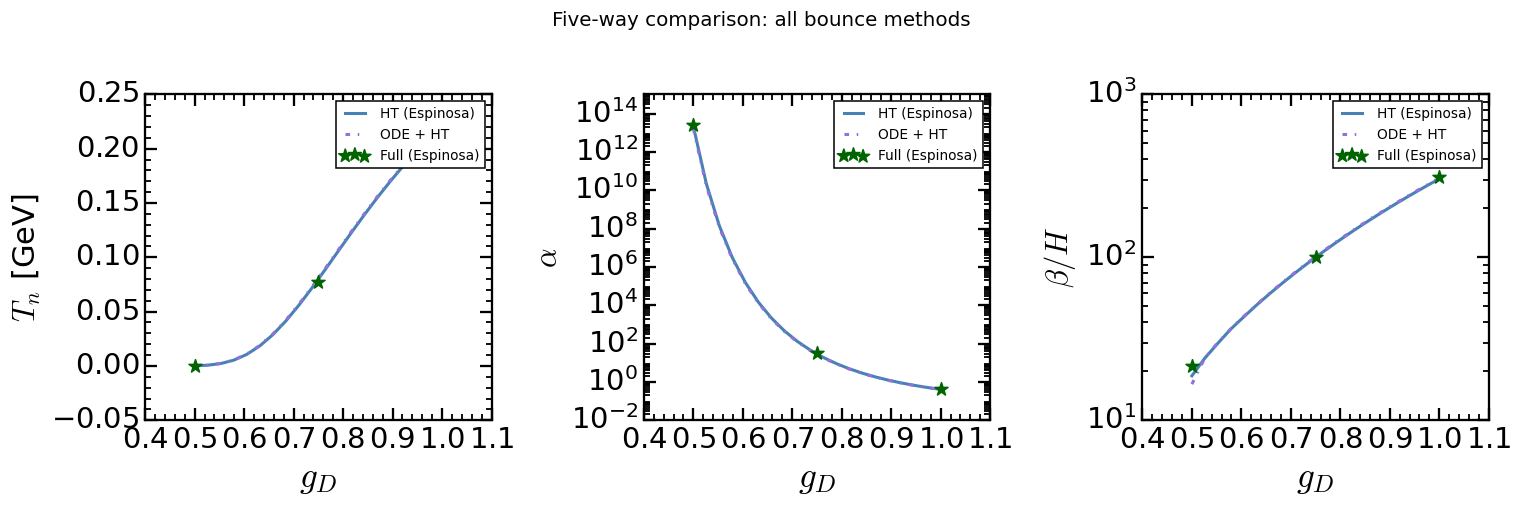

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=110)
fig.patch.set_facecolor('white')

# Line plots for methods with full gD coverage
line_styles = [
    ("HT (Espinosa)",  gD_vals,      Tn_vals,          alpha_vals,          beta_vals,          'steelblue',   '-'),
    #("Grid",           gD_vals_grid, Tn_vals_grid,     alpha_vals_grid,     beta_vals_grid,     'firebrick',   ':'),
    ("ODE + HT",       gD_vals,      Tn_vals_ode_ht,   alpha_vals_ode_ht,   beta_vals_ode_ht,   'mediumpurple','-.'),
   # ("ODE + Full",     gD_vals,      Tn_vals_ode_full, alpha_vals_ode_full, beta_vals_ode_full, 'darkorange',  'P--'),
]
for label, gd_v, Tn_v, a_v, b_v, color, ls in line_styles:
    m_Tn = np.isfinite(Tn_v)
    axes[0].plot(gd_v[m_Tn],                          Tn_v[m_Tn],                          ls, lw=2, color=color, label=label)
    axes[1].plot(gd_v[m_Tn & np.isfinite(a_v)],      a_v[m_Tn & np.isfinite(a_v)],      ls, lw=2, color=color, label=label)
    axes[2].plot(gd_v[m_Tn & np.isfinite(b_v)],      b_v[m_Tn & np.isfinite(b_v)],      ls, lw=2, color=color, label=label)

# Full (Espinosa): scatter only (3 points)
m_full = np.isfinite(Tn_vals_full)
axes[0].scatter(gD_vals_full[m_full],                                Tn_vals_full[m_full],                                s=80, marker='*', color='darkgreen', zorder=5, label='Full (Espinosa)')
axes[1].scatter(gD_vals_full[m_full & np.isfinite(alpha_vals_full)], alpha_vals_full[m_full & np.isfinite(alpha_vals_full)], s=80, marker='*', color='darkgreen', zorder=5, label='Full (Espinosa)')
axes[2].scatter(gD_vals_full[m_full & np.isfinite(beta_vals_full)],  beta_vals_full[m_full & np.isfinite(beta_vals_full)],  s=80, marker='*', color='darkgreen', zorder=5, label='Full (Espinosa)')

ps.apply_standard_formatting(axes[0], xlabel=r'$g_D$', ylabel=r'$T_n$ [GeV]')
ps.apply_standard_formatting(axes[1], ylog=True, xlabel=r'$g_D$', ylabel=r'$\alpha$')
ps.apply_standard_formatting(axes[2], ylog=True, xlabel=r'$g_D$', ylabel=r'$\beta/H$')

for ax_i in axes:
    ax_i.legend(fontsize=9)
    ax_i.text(0.97, 0.95, r'$\mu = \pi T$', transform=ax_i.transAxes,
              ha='right', va='top', fontsize=10, color='gray')

plt.suptitle("Five-way comparison: all bounce methods", fontsize=13, y=1.02)
plt.tight_layout()